## The Dataset

we will be using a CSV file titled `premier-player-23-24.csv`, which contains information on all players in Premier League season 2023-2024. The dataset includes the following columns:
- `Player`:Name of the player.
- `Nation`:The player's nationality.
- `Pos`:The position(s) the player typically plays (e.g., FW, MF, DF, GK).
- `Age`:The player's age.
- `MP`:Matches Played – The number of games the player appeared in.
- `Starts`:The number of games the player started.
- `Min`:Total minutes played.
- `90s (90s Played)`:The equivalent of 90-minute matches played by the player (e.g., 1.5 = 135 minutes).
- `Gls(Goals)`:Total number of goals scored by the player.
- `Ast(Assists)`: Total number of assists made by the player.
- `G+A (Goals + Assists)`:  Total number of goals and assists combined.
- `G-PK (Goals - Penalty Kicks)`:Total number of goals scored excluding penalty kicks.
- `PK (Penalty Kicks)`:Number of penalty goals scored by the player.
- `PKatt (Penalty Kicks Attempted)`:Number of penalty kicks attempted by the player.
- `CrdY (Yellow Cards)`:Number of yellow cards received by the player.
- `CrdR (Red Cards)`:Number of red cards received by the player.
- `xG (Expected Goals)`:The expected number of goals from the player's shots.
- `npxG (Non-Penalty Expected Goals)`:Expected goals excluding penalties.
- `xAG (Expected Assists)`:The expected number of assists from the player's passes.
- `npxG+xAG (Non-Penalty xG + xAG)`:Total of non-penalty expected goals and expected assists.
- `PrgC (Progressive Carries)`:Number of times the player carried the ball forward.
- `PrgP (Progressive Passes)`:Number of passes made by the player that moved the ball forward.
- `PrgR (Progressive Runs)`:Number of times the player made runs forward with the ball.
- `Gls_90`: Goals per 90 minutes.
- `Ast_90`:Assists per 90 minutes.
- `G+A_90`:Goals + Assists per 90 minutes.
- `G-PK_90`:Non-penalty goals per 90 minutes.
- `G+A-PK_90`:Goals + Assists (excluding penalties) per 90 minutes.
- `xG_90`:Expected Goals per 90 minutes.
- `xAG_90`:Expected Assists per 90 minutes.
- `xG+xAG_90`:Expected Goals + Expected Assists per 90 minutes.
- `npxG_90`:Non-penalty Expected Goals per 90 minutes.
- `npxG+xAG_90`: Non-penalty Expected Goals + Expected Assists per 90 minutes.


## Getting started

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

In [20]:
file_path = "/content/premier-player-23-24.csv"

we going to check if the file exists before proceeding

In [21]:
if not os.path.exists(file_path):
    print("File not found! Please check the file path.")
else:
    # Load the data
    df = pd.read_csv(file_path)
    print(f"File loaded successfully: {file_path}")

File loaded successfully: /content/premier-player-23-24.csv


# We will process the dataset by resolving missing data, eliminating duplicates, verifying, and saving the cleaned data.

Visualizing missing data...


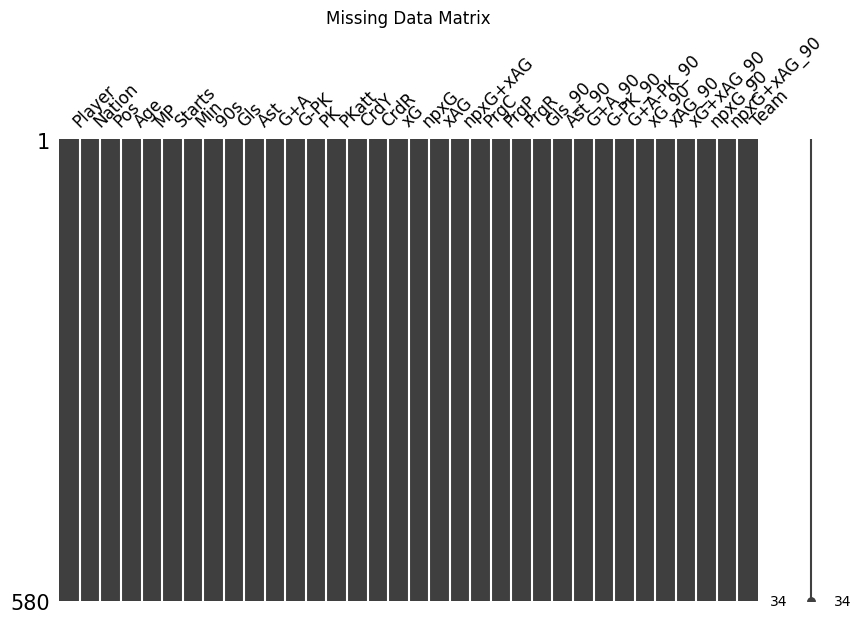

In [22]:
print("Visualizing missing data...")
msno.matrix(df, figsize=(10, 6), fontsize=12)
plt.title("Missing Data Matrix")
plt.show()


As we can see there is no missing data

- Here we going to delete the dublicate records if there was any dublicts

In [23]:
duplicates_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed {duplicates_count} duplicate records.")

Removed 0 duplicate records.


In [24]:
df.dtypes

,0
Player,object
Nation,object
Pos,object
Age,float64
MP,int64
Starts,int64
Min,float64
90s,float64
Gls,float64
Ast,float64


As we can see, some data types are incorrect, and this has to be fixed.

# The data types we need change is
`Age`
`Min`
`Gls`
`Ast`
`G+A`
`G-PK`
`PK`
`PKatt`
`CrdY`
`CrdR`
`PrgC`
`PrgP`
`PrgR`

In [25]:
# 3. Reformatting/Converting Data Types
df['Age']=df['Age'].astype(int)
df['Gls']=df['Gls'].astype(int)
df['Min']=df['Min'].astype(int)
df['Ast']=df['Ast'].astype(int)
df['G+A']=df['G+A'].astype(int)
df['G-PK']=df['G-PK'].astype(int)
df['PK']=df['PK'].astype(int)
df['PKatt']=df['PKatt'].astype(int)
df['CrdY']=df['CrdY'].astype(int)
df['CrdR']=df['CrdR'].astype(int)
df['PrgC']=df['PrgC'].astype(int)
df['PrgP']=df['PrgP'].astype(int)
df['PrgR']=df['PrgR'].astype(int)


In [26]:
df.dtypes

,0
Player,object
Nation,object
Pos,object
Age,int64
MP,int64
Starts,int64
Min,int64
90s,float64
Gls,int64
Ast,int64


now we move on after we fixed the data types

# We will examine the dataset to see if any negative values exist.

In [27]:
# 4. Validate Data
# Check for negative values
negative_values = {col: df[df[col] < 0].shape[0] for col in ["Age", "Gls", "xG_90", "Min"] if (df[col] < 0).any()}
print("Negative value counts:", negative_values)


Negative value counts: {}


# Now we going to check for invalid ranges

In [28]:
invalid_age = df[(df['Age'] < 16) | (df['Age'] > 50)]
print("Invalid ages found:\n", invalid_age)

Invalid ages found:
           Player   Nation Pos  Age  MP  Starts  Min  90s  Gls  Ast  ...  \
171  Mikey Moore  eng ENG  MF   15   2       0    4  0.0    0    0  ...   

     Ast_90  G+A_90  G-PK_90  G+A-PK_90  xG_90  xAG_90  xG+xAG_90  npxG_90  \
171     0.0     0.0      0.0        0.0    0.0     0.0        0.0      0.0   

     npxG+xAG_90               Team  
171          0.0  Tottenham Hotspur  

[1 rows x 34 columns]


**Decision:** Mikey Moore (age 15) is a legitimate Premier League player. We keep the record but add a note that he is below the typical 16-50 age range.


# Save the file

## Summary Statistics


In [29]:
# Quick statistical overview of the cleaned dataset
df.describe()


,Age,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,...,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,...,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,24.906897,19.627586,14.413793,1294.584483,14.383448,2.063793,1.481034,3.544828,1.898276,0.165517,...,0.125259,0.091621,0.216810,0.118155,0.209638,0.144983,0.100707,0.245845,0.138431,0.239466
std,4.464593,11.832419,11.926422,1024.720358,11.385342,3.621238,2.360729,5.391389,3.189739,0.779830,...,0.223161,0.160703,0.297085,0.214342,0.287035,0.222225,0.210713,0.348004,0.213947,0.340631
min,15.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,9.000000,3.000000,342.750000,3.775000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.017500,0.010000,0.060000,0.017500,0.060000
50%,25.000000,20.000000,13.000000,1164.000000,12.950000,1.000000,0.000000,1.000000,1.000000,0.000000,...,0.030000,0.000000,0.100000,0.030000,0.100000,0.070000,0.060000,0.145000,0.070000,0.145000
75%,28.000000,30.000000,25.000000,2104.250000,23.400000,2.000000,2.000000,4.000000,2.000000,0.000000,...,0.170000,0.130000,0.310000,0.160000,0.300000,0.190000,0.140000,0.370000,0.180000,0.350000
max,38.000000,38.000000,38.000000,3420.000000,38.000000,27.000000,13.000000,33.000000,20.000000,9.000000,...,2.650000,1.700000,2.650000,2.650000,2.650000,3.230000,4.440000,5.540000,3.230000,5.540000


In [30]:
processed_file_path = 'processed_data.csv'
df.to_csv(processed_file_path, index=False)
print(f"Data saved to {processed_file_path}")

Data saved to processed_data.csv


# We going now to analyzing the data

In [31]:
# Function to analyze specific teams
def analyze_teams(data, teams):
    filtered_data = data[data['Team'].isin(teams)]
    metrics = filtered_data.groupby('Team').agg(
        avg_goals=('Gls', 'mean'),
        avg_assists=('Ast', 'mean'),
        avg_minutes=('Min', 'mean'),
        total_goals=('Gls', 'sum'),
        total_assists=('Ast', 'sum')
    ).sort_values(by='avg_goals', ascending=False)
    return metrics


# Calculate total goals scored by top 5 teams

In [32]:
# Calculate total goals scored by each team
team_goals = df.groupby("Team")["Gls"].sum().sort_values(ascending=False)
print("Top 5 teams by total goals scored:")
print(team_goals.head())


Top 5 teams by total goals scored:
Team
Manchester City     94
Arsenal             86
Newcastle United    83
Liverpool           80
Chelsea             76
Name: Gls, dtype: int64


In [33]:

teams_of_interest = ['Manchester City', 'Arsenal', 'Liverpool']
team_performance = analyze_teams(df, teams_of_interest)
print("Team performance metrics:")
print(team_performance)



Team performance metrics:
                 avg_goals  avg_assists  avg_minutes  total_goals  \
Team                                                                
Manchester City   3.760000         2.76      1502.96           94   
Arsenal           3.440000         2.48      1503.52           86   
Liverpool         2.666667         2.00      1247.80           80   

                 total_assists  
Team                            
Manchester City             69  
Arsenal                     62  
Liverpool                   60  


# Top 10 players goals

In [34]:
top_xg_players = df[df['Gls'] >= 10].sort_values('Gls', ascending=False).head(10)
print("Top 10 players with the highest xG (minimum 10 goals):")
print(top_xg_players[['Player', 'Team', 'Gls', 'xG']])

Top 10 players with the highest xG (minimum 10 goals):
                   Player               Team  Gls    xG
6          Erling Haaland    Manchester City   27  29.2
83            Cole Palmer            Chelsea   22  18.2
117        Alexander Isak   Newcastle United   21  20.3
1              Phil Foden    Manchester City   19  10.3
369       Dominic Solanke        Bournemouth   19  19.6
204         Ollie Watkins        Aston Villa   19  16.8
28          Mohamed Salah          Liverpool   18  21.2
146         Son Heung-min  Tottenham Hotspur   17  12.0
59            Bukayo Saka            Arsenal   16  15.5
265  Jean-Philippe Mateta     Crystal Palace   16  10.9


# Top 10 players assists

In [35]:
top_xag_players = df[df['Ast'] >= 10].sort_values('Ast', ascending=False).head(10)
print("\nTop 10 players with the highest xAG (minimum 10 assists):")
print(top_xag_players[['Player', 'Team', 'Ast', 'xAG']])



Top 10 players with the highest xAG (minimum 10 assists):
              Player               Team  Ast   xAG
204    Ollie Watkins        Aston Villa   13   7.3
83       Cole Palmer            Chelsea   11  11.1
13   Kevin De Bruyne    Manchester City   10  11.5
57   Martin Ødegaard            Arsenal   10   9.6
28     Mohamed Salah          Liverpool   10  11.8
118  Kieran Trippier   Newcastle United   10   7.5
114   Anthony Gordon   Newcastle United   10   8.0
146    Son Heung-min  Tottenham Hotspur   10  11.8
154  Brennan Johnson  Tottenham Hotspur   10   8.1
338      Pascal Groß           Brighton   10   8.1


# Top 10 players with the highest xG who have scored at least 10 goals

In [36]:
top_xg_players = df[df['Gls'] >= 10].sort_values('xG', ascending=False).head(10)
print("Top 10 players with the highest xG (minimum 10 goals):")
print(top_xg_players[['Player', 'Team', 'Gls', 'xG']])

Top 10 players with the highest xG (minimum 10 goals):
              Player              Team  Gls    xG
6     Erling Haaland   Manchester City   27  29.2
28     Mohamed Salah         Liverpool   18  21.2
117   Alexander Isak  Newcastle United   21  20.3
369  Dominic Solanke       Bournemouth   19  19.6
82   Nicolas Jackson           Chelsea   14  18.6
83       Cole Palmer           Chelsea   22  18.2
204    Ollie Watkins       Aston Villa   19  16.8
32      Darwin Núñez         Liverpool   11  16.3
59       Bukayo Saka           Arsenal   16  15.5
3     Julián Álvarez   Manchester City   11  13.0


# Top 10 players with the highest xAG who have provided at least 10 assists

In [37]:
top_xag_players = df[df['Ast'] >= 10].sort_values('xAG', ascending=False).head(10)
print("\nTop 10 players with the highest xAG (minimum 10 assists):")
print(top_xag_players[['Player', 'Team', 'Ast', 'xAG']])



Top 10 players with the highest xAG (minimum 10 assists):
                 Player               Team  Ast   xAG
28        Mohamed Salah          Liverpool   10  11.8
146       Son Heung-min  Tottenham Hotspur   10  11.8
13      Kevin De Bruyne    Manchester City   10  11.5
83          Cole Palmer            Chelsea   11  11.1
57      Martin Ødegaard            Arsenal   10   9.6
453  Morgan Gibbs-White  Nottingham Forest   10   8.4
154     Brennan Johnson  Tottenham Hotspur   10   8.1
338         Pascal Groß           Brighton   10   8.1
114      Anthony Gordon   Newcastle United   10   8.0
118     Kieran Trippier   Newcastle United   10   7.5


# Age and Performance Analysis

<Axes: xlabel='Age', ylabel='Gls'>

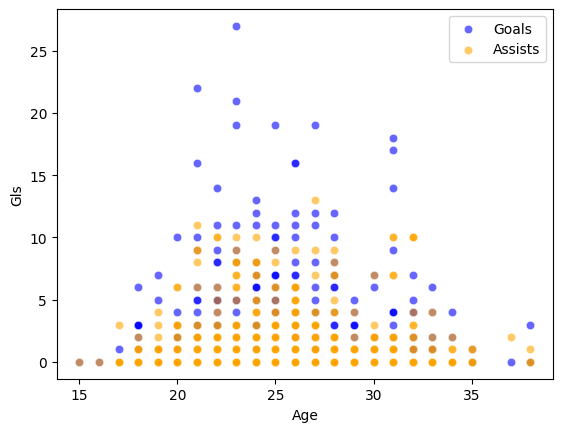

In [38]:
age_performance = df[['Age', 'Gls', 'Ast', 'Min']]
sns.scatterplot(data=age_performance, x='Age', y='Gls', alpha=0.6, color='blue', label='Goals')
sns.scatterplot(data=age_performance, x='Age', y='Ast', alpha=0.6, color='orange', label='Assists')

# Discipline Analysis

<Axes: xlabel='Team'>

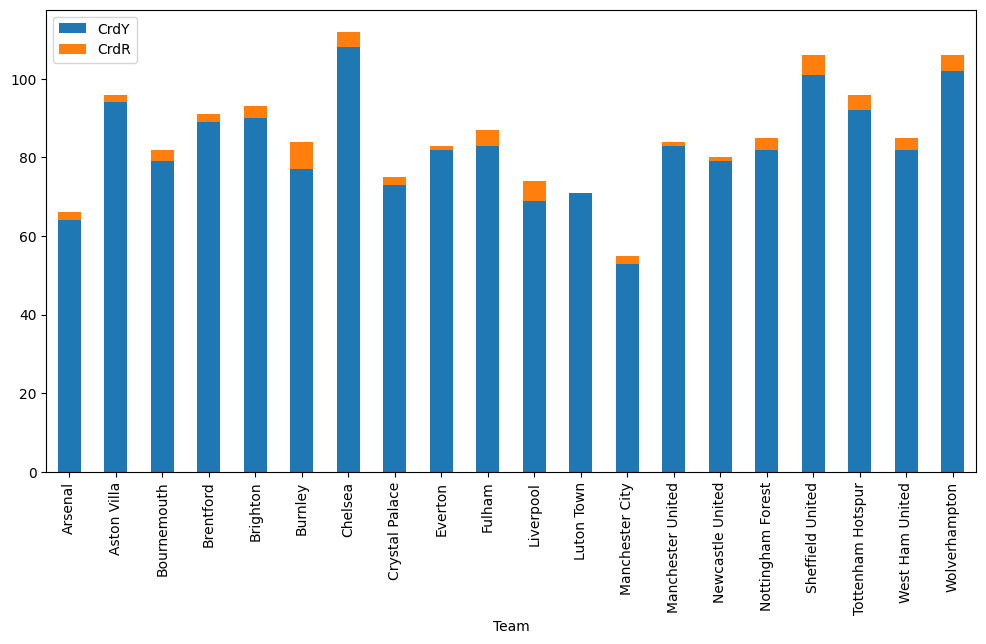

In [39]:
discipline_by_team = df.groupby('Team')[['CrdY', 'CrdR']].sum()
discipline_by_pos = df.groupby('Pos')[['CrdY', 'CrdR']].sum()
discipline_by_team.plot(kind='bar', stacked=True, figsize=(12, 6))

 # Team Style of Play (Progressive Metrics)
        


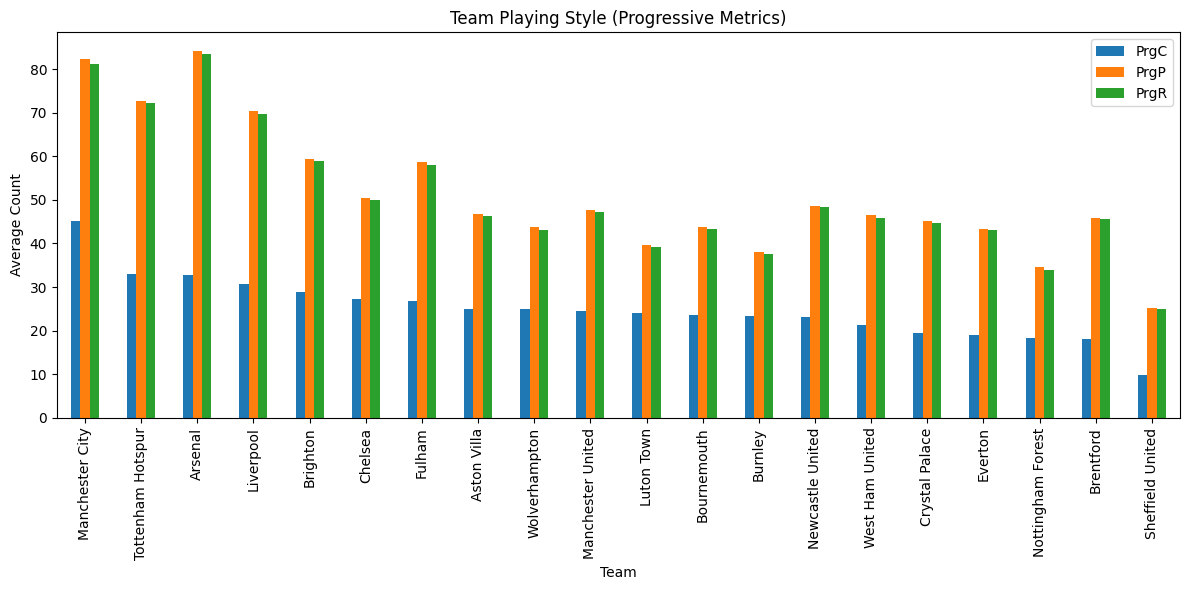

In [40]:
team_play_style = df.groupby('Team')[['PrgC', 'PrgP', 'PrgR']].mean()
team_play_style.sort_values('PrgC', ascending=False).plot(kind='bar', figsize=(12, 6))
plt.title('Team Playing Style (Progressive Metrics)')
plt.ylabel('Average Count')
plt.xlabel('Team')
plt.tight_layout()
plt.show()


# Team Efficiency: Actual Goals vs Expected Goals

<Axes: xlabel='Team'>

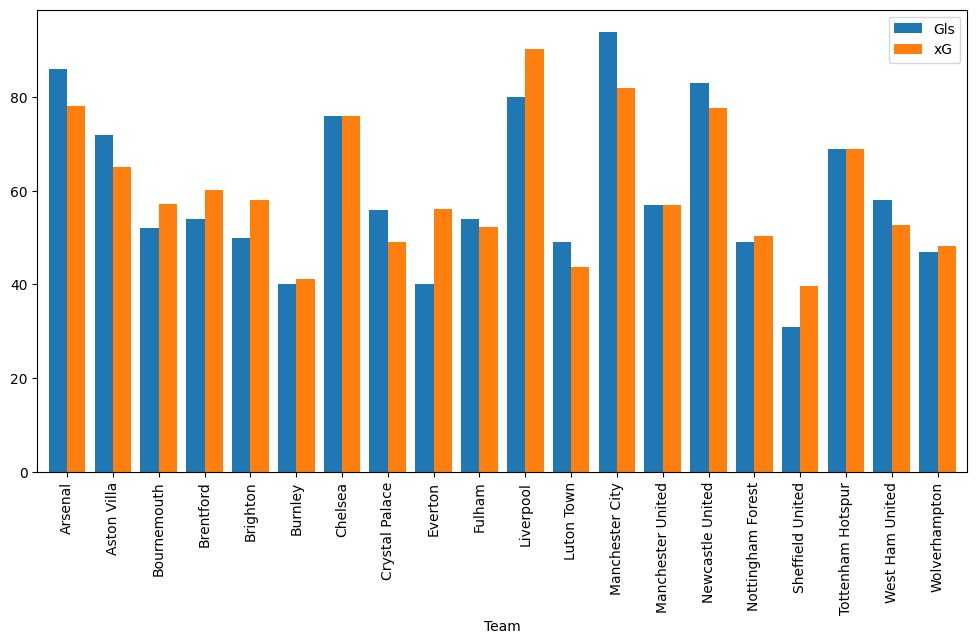

In [41]:
team_efficiency = df.groupby('Team')[['Gls', 'xG']].sum()
team_efficiency['Efficiency_Ratio'] = team_efficiency['Gls'] / team_efficiency['xG']
team_efficiency[['Gls', 'xG']].plot(kind='bar', figsize=(12, 6), width=0.8)

# Efficiency Metrics: Goal Conversion Rate and Assist Over/Underperformance

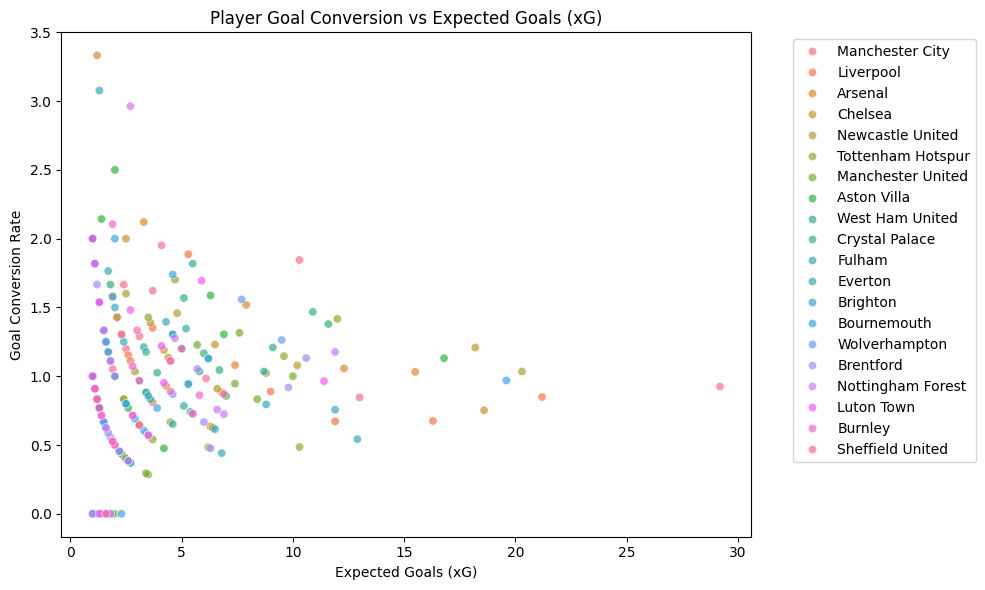

In [42]:
# Calculate efficiency metrics before plotting
efficiency_metrics = df.copy()
efficiency_metrics = efficiency_metrics[efficiency_metrics['xG'] >= 1.0].copy() # Filter out extreme outliers with very low xG
efficiency_metrics['Goal_Conversion'] = efficiency_metrics['Gls'] / efficiency_metrics['xG']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=efficiency_metrics, x='xG', y='Goal_Conversion', hue='Team', alpha=0.7)
plt.title('Player Goal Conversion vs Expected Goals (xG)')
plt.xlabel('Expected Goals (xG)')
plt.ylabel('Goal Conversion Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


# Total Goals by Team

/tmp/ipykernel_6722/1042733695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_goals.index, y=team_goals.values, palette="viridis")


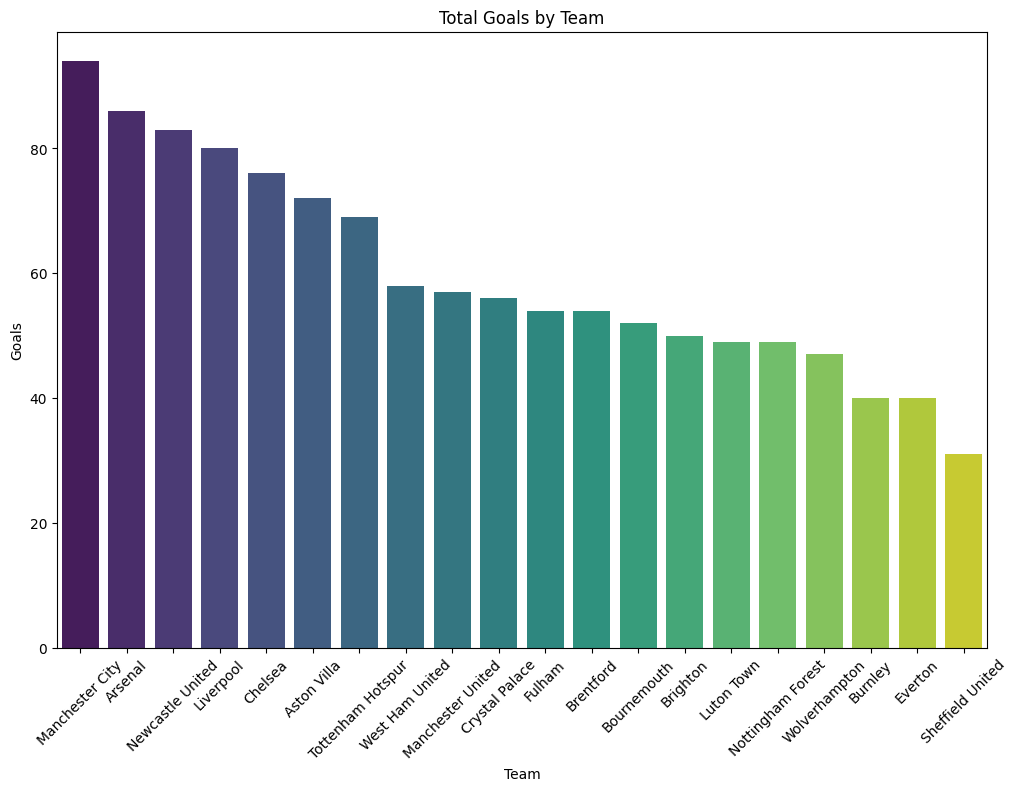

In [43]:
# Visualization: Total goals by team
plt.figure(figsize=(12, 8))
sns.barplot(x=team_goals.index, y=team_goals.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Total Goals by Team")
plt.ylabel("Goals")
plt.xlabel("Team")
plt.show()

# Distribution of Player Nationalities

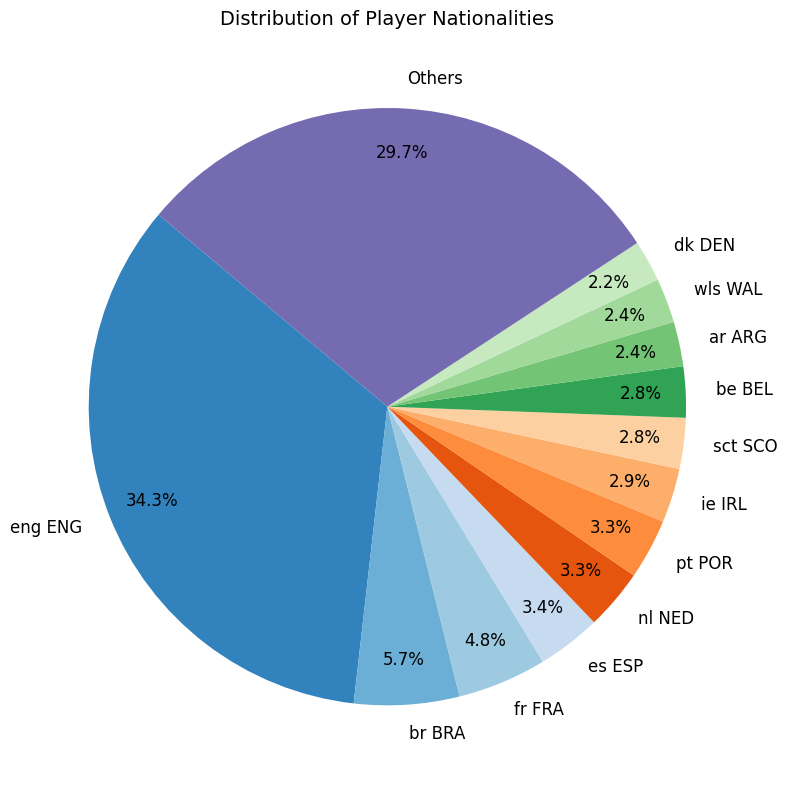

In [44]:
# Group smaller categories into "Others"
threshold = 2  # Set a percentage threshold for grouping
nationality_counts = df['Nation'].value_counts(normalize=True) * 100
major_nationalities = nationality_counts[nationality_counts > threshold]
others = nationality_counts[nationality_counts <= threshold].sum()

# Create a new Series with "Others" included
pie_data = pd.concat([major_nationalities, pd.Series({'Others': others})])


plt.figure(figsize=(10, 8))
pie_data.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab20c', len(pie_data)),
    textprops={'fontsize': 12},
    pctdistance=0.85
)
plt.title("Distribution of Player Nationalities", fontsize=14)
plt.ylabel("")  # Hide y-axis label
plt.tight_layout()
plt.show()


# Age Distribution

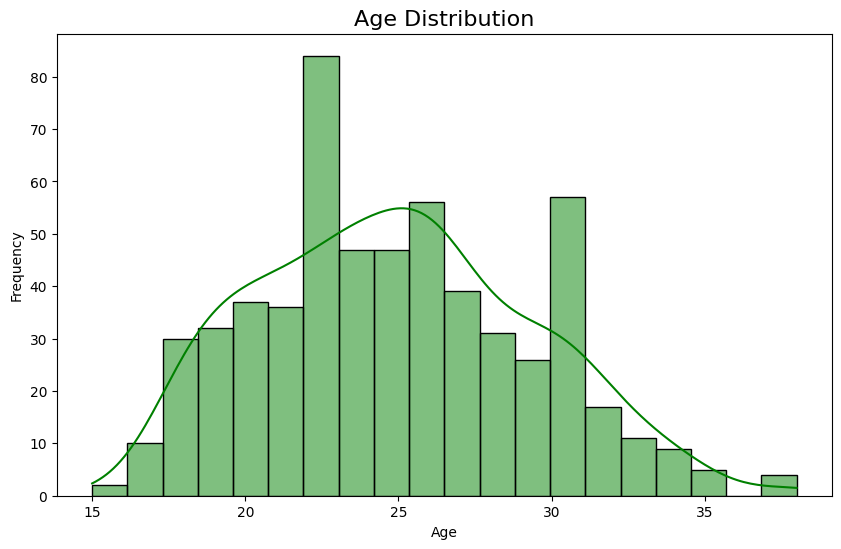

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='green')
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Correlation Heatmap


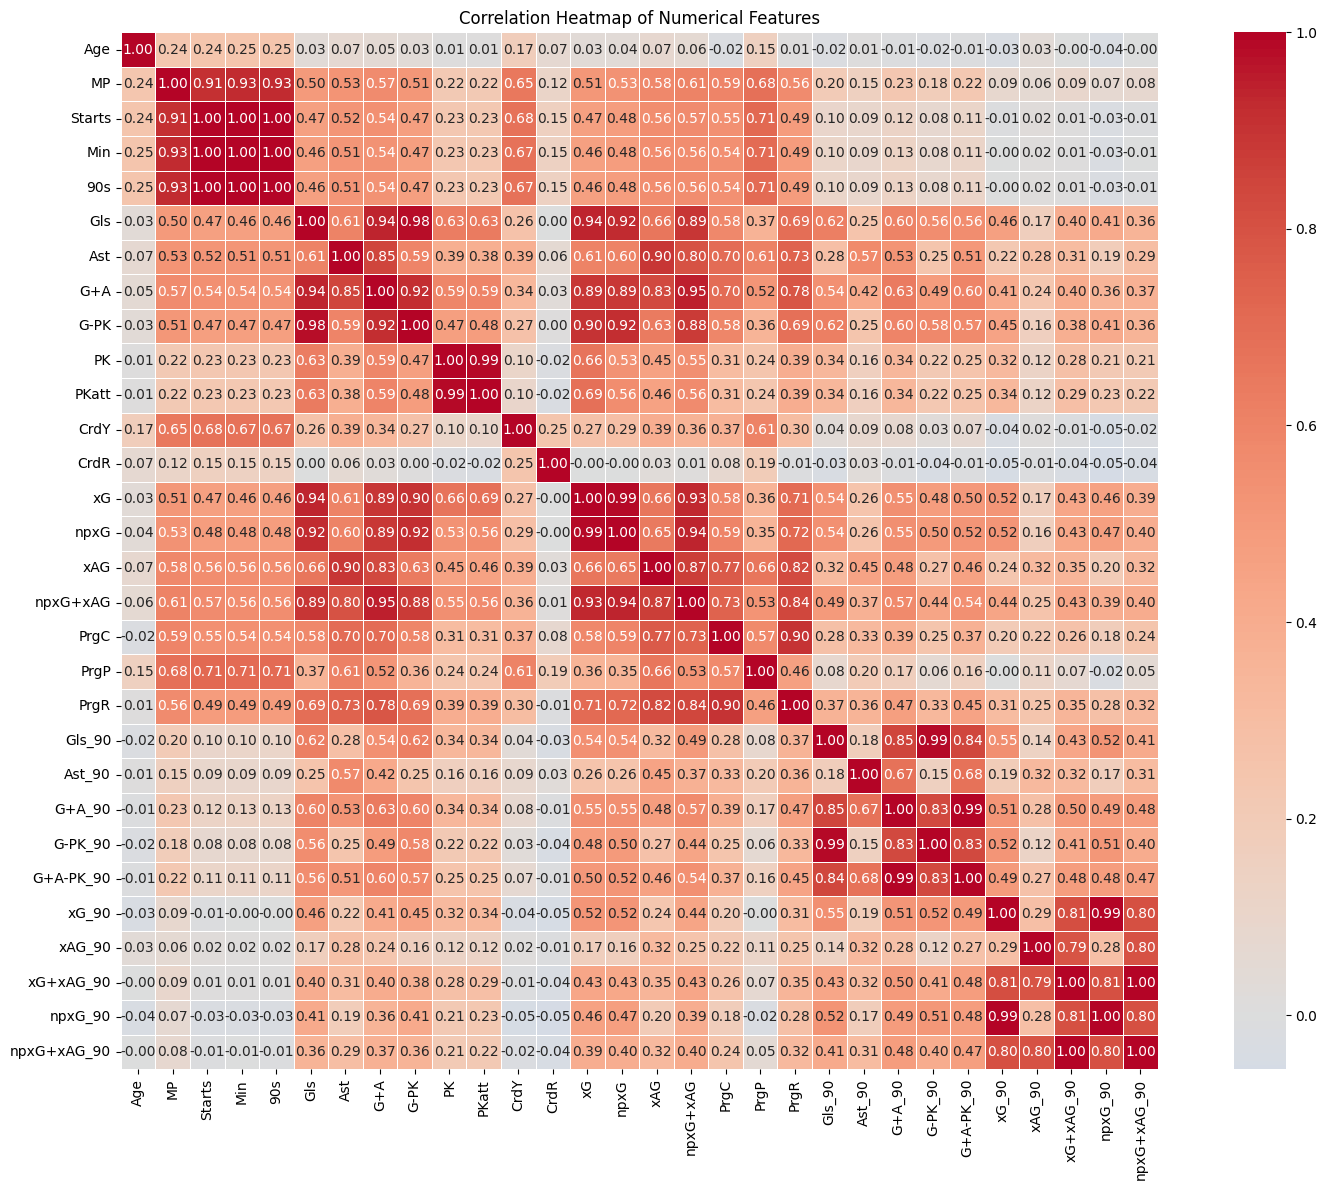

In [46]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


# Position-Based Analysis


Average stats by position:
             avg_goals  avg_assists    avg_xG  avg_minutes  player_count
Primary_Pos                                                             
FW            4.528302     2.176101  4.450943  1108.031447           159
MF            1.738889     1.727778  1.798333  1220.183333           180
DF            0.815920     0.995025  0.859204  1426.114428           201
GK            0.000000     0.050000  0.000000  1710.000000            40


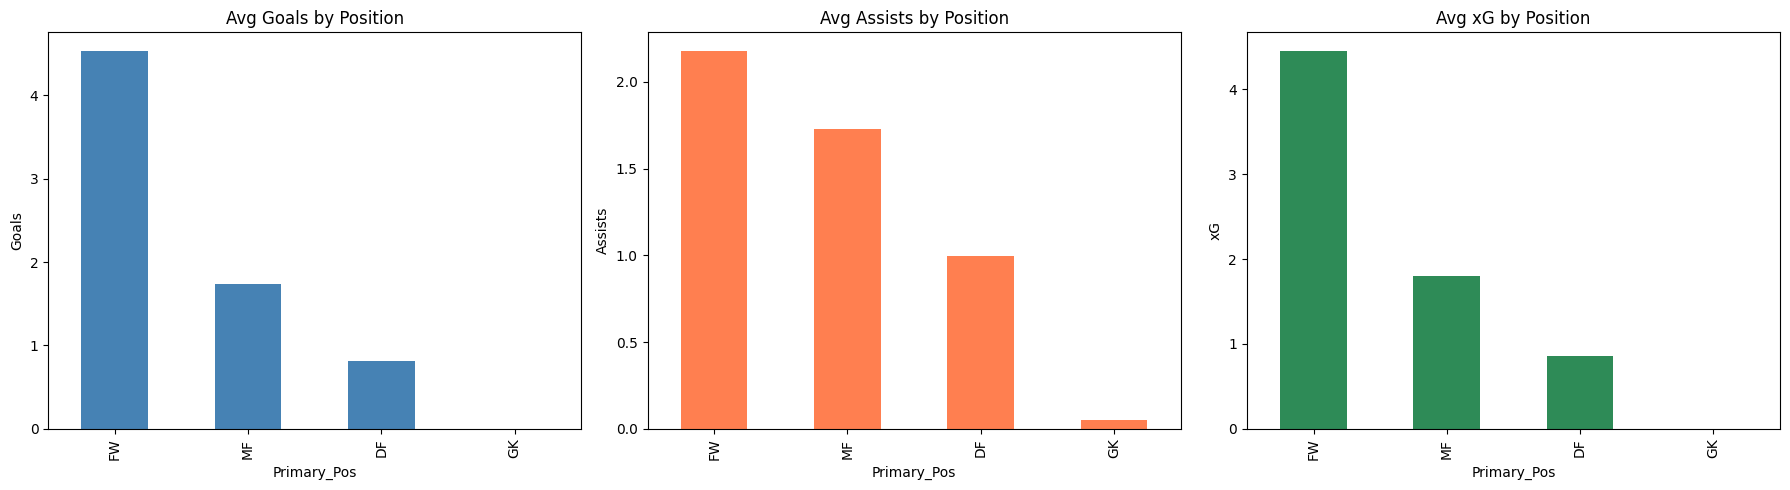

In [47]:
# Extract primary position (first listed)
df['Primary_Pos'] = df['Pos'].apply(lambda x: str(x).split(',')[0] if ',' in str(x) else str(x))

pos_metrics = df.groupby('Primary_Pos').agg(
    avg_goals=('Gls', 'mean'),
    avg_assists=('Ast', 'mean'),
    avg_xG=('xG', 'mean'),
    avg_minutes=('Min', 'mean'),
    player_count=('Player', 'count')
).sort_values('avg_goals', ascending=False)

print('Average stats by position:')
print(pos_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pos_metrics['avg_goals'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Goals by Position')
axes[0].set_ylabel('Goals')

pos_metrics['avg_assists'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Assists by Position')
axes[1].set_ylabel('Assists')

pos_metrics['avg_xG'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Avg xG by Position')
axes[2].set_ylabel('xG')

plt.tight_layout()
plt.show()


# Per-90 Minute Statistics (players with ≥ 900 minutes)


Top 15 players by Goals per 90 (min 900 Min):
              Player              Team  Gls_90  xG_90
      Erling Haaland   Manchester City    0.95   1.03
      Alexander Isak  Newcastle United    0.84   0.81
       Callum Wilson  Newcastle United    0.82   0.80
          Diogo Jota         Liverpool    0.79   0.42
         Cole Palmer           Chelsea    0.76   0.63
       Michael Olise    Crystal Palace    0.71   0.39
          Chris Wood Nottingham Forest    0.70   0.59
         Richarlison Tottenham Hotspur    0.66   0.58
    Leandro Trossard           Arsenal    0.65   0.43
       Mohamed Salah         Liverpool    0.64   0.75
Jean-Philippe Mateta    Crystal Palace    0.63   0.43
      Elijah Adebayo        Luton Town    0.63   0.37
          Phil Foden   Manchester City    0.60   0.33
       Ollie Watkins       Aston Villa    0.53   0.47
       Son Heung-min Tottenham Hotspur    0.52   0.37



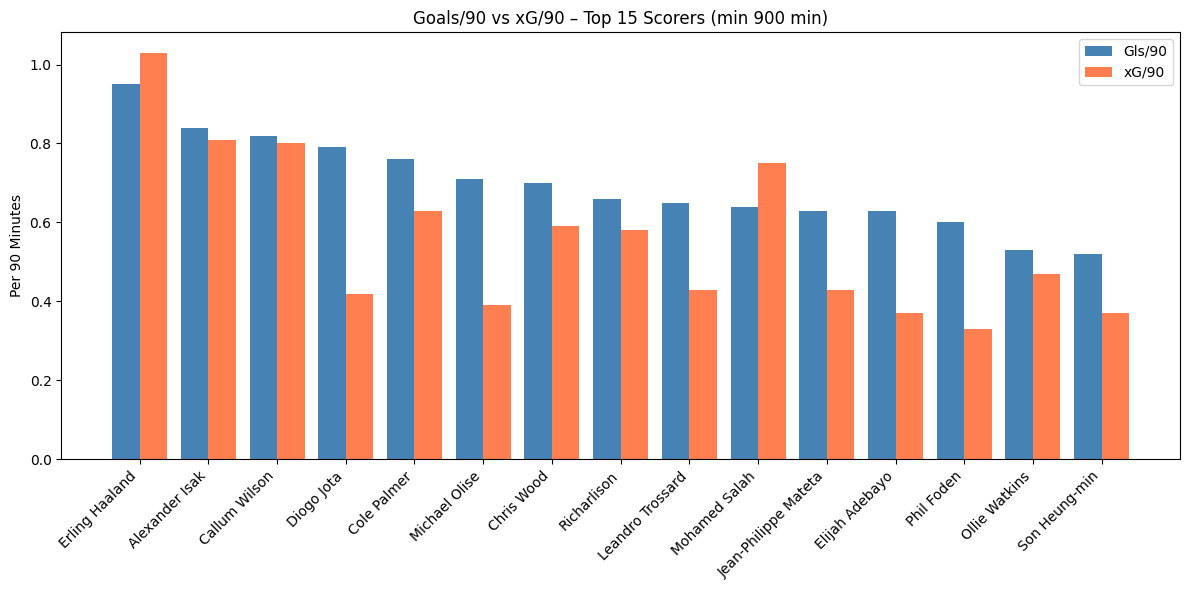

In [48]:
# Filter for players with meaningful minutes
qualified = df[df['Min'] >= 900].copy()

# Top 15 players by Goals per 90
top_gls90 = qualified.nlargest(15, 'Gls_90')[['Player', 'Team', 'Gls_90', 'xG_90']]
print('Top 15 players by Goals per 90 (min 900 Min):')
print(top_gls90.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top_gls90))
ax.bar([i - 0.2 for i in x], top_gls90['Gls_90'], width=0.4, label='Gls/90', color='steelblue')
ax.bar([i + 0.2 for i in x], top_gls90['xG_90'], width=0.4, label='xG/90', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(top_gls90['Player'], rotation=45, ha='right')
ax.set_ylabel('Per 90 Minutes')
ax.set_title('Goals/90 vs xG/90 – Top 15 Scorers (min 900 min)')
ax.legend()
plt.tight_layout()
plt.show()


# xG Over/Underperformance (players with ≥ 10 goals)


Goal Conversion: Actual Goals minus Expected Goals
              Player              Team  Gls   xG  xG_diff
          Phil Foden   Manchester City   19 10.3      8.7
Jean-Philippe Mateta    Crystal Palace   16 10.9      5.1
       Son Heung-min Tottenham Hotspur   17 12.0      5.0
          Diogo Jota         Liverpool   10  5.3      4.7
       Michael Olise    Crystal Palace   10  5.5      4.5
        Jarrod Bowen   West Ham United   16 11.6      4.4
      Hwang Hee-chan     Wolverhampton   12  7.7      4.3
    Leandro Trossard           Arsenal   12  7.9      4.1
      Elijah Adebayo        Luton Town   10  5.9      4.1
         Cole Palmer           Chelsea   22 18.2      3.8
         Leon Bailey       Aston Villa   10  6.3      3.7
       Matheus Cunha     Wolverhampton   12  9.5      2.5
      Rasmus Højlund Manchester United   10  7.6      2.4
       Ollie Watkins       Aston Villa   19 16.8      2.2
          Chris Wood Nottingham Forest   14 11.9      2.1
        Eberechi Eze 

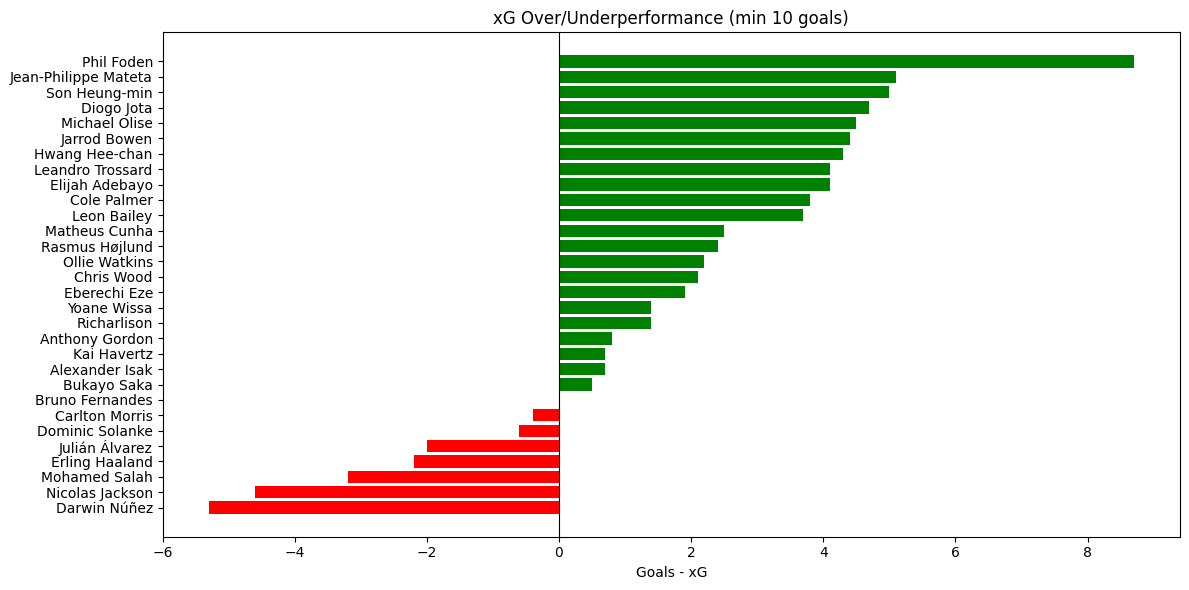

In [49]:
qualified_scorers = df[df['Gls'] >= 10].copy()
qualified_scorers['xG_diff'] = qualified_scorers['Gls'] - qualified_scorers['xG']
qualified_scorers = qualified_scorers.sort_values('xG_diff', ascending=False)

print('Goal Conversion: Actual Goals minus Expected Goals')
print(qualified_scorers[['Player', 'Team', 'Gls', 'xG', 'xG_diff']].to_string(index=False))
print()

colors = ['green' if x >= 0 else 'red' for x in qualified_scorers['xG_diff']]
plt.figure(figsize=(12, 6))
plt.barh(qualified_scorers['Player'], qualified_scorers['xG_diff'], color=colors)
plt.xlabel('Goals - xG')
plt.title('xG Over/Underperformance (min 10 goals)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Nationality Breakdown


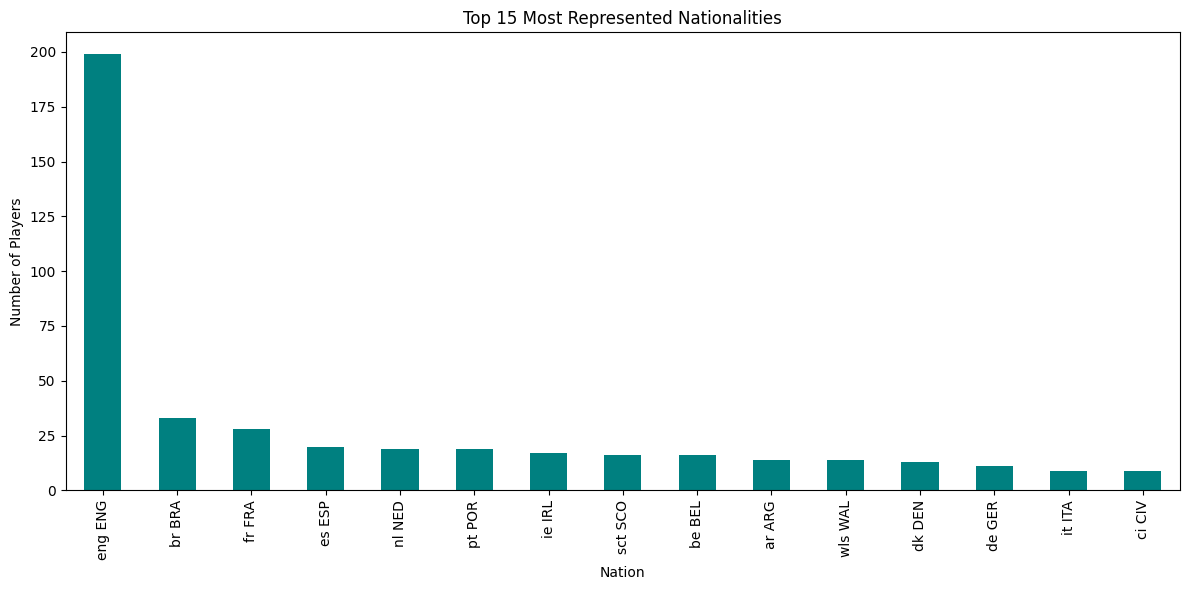

In [50]:
nation_counts = df['Nation'].value_counts().head(15)
plt.figure(figsize=(12, 6))
nation_counts.plot(kind='bar', color='teal')
plt.title('Top 15 Most Represented Nationalities')
plt.xlabel('Nation')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()


# Distribution of Key Stats by Position (Box Plots)


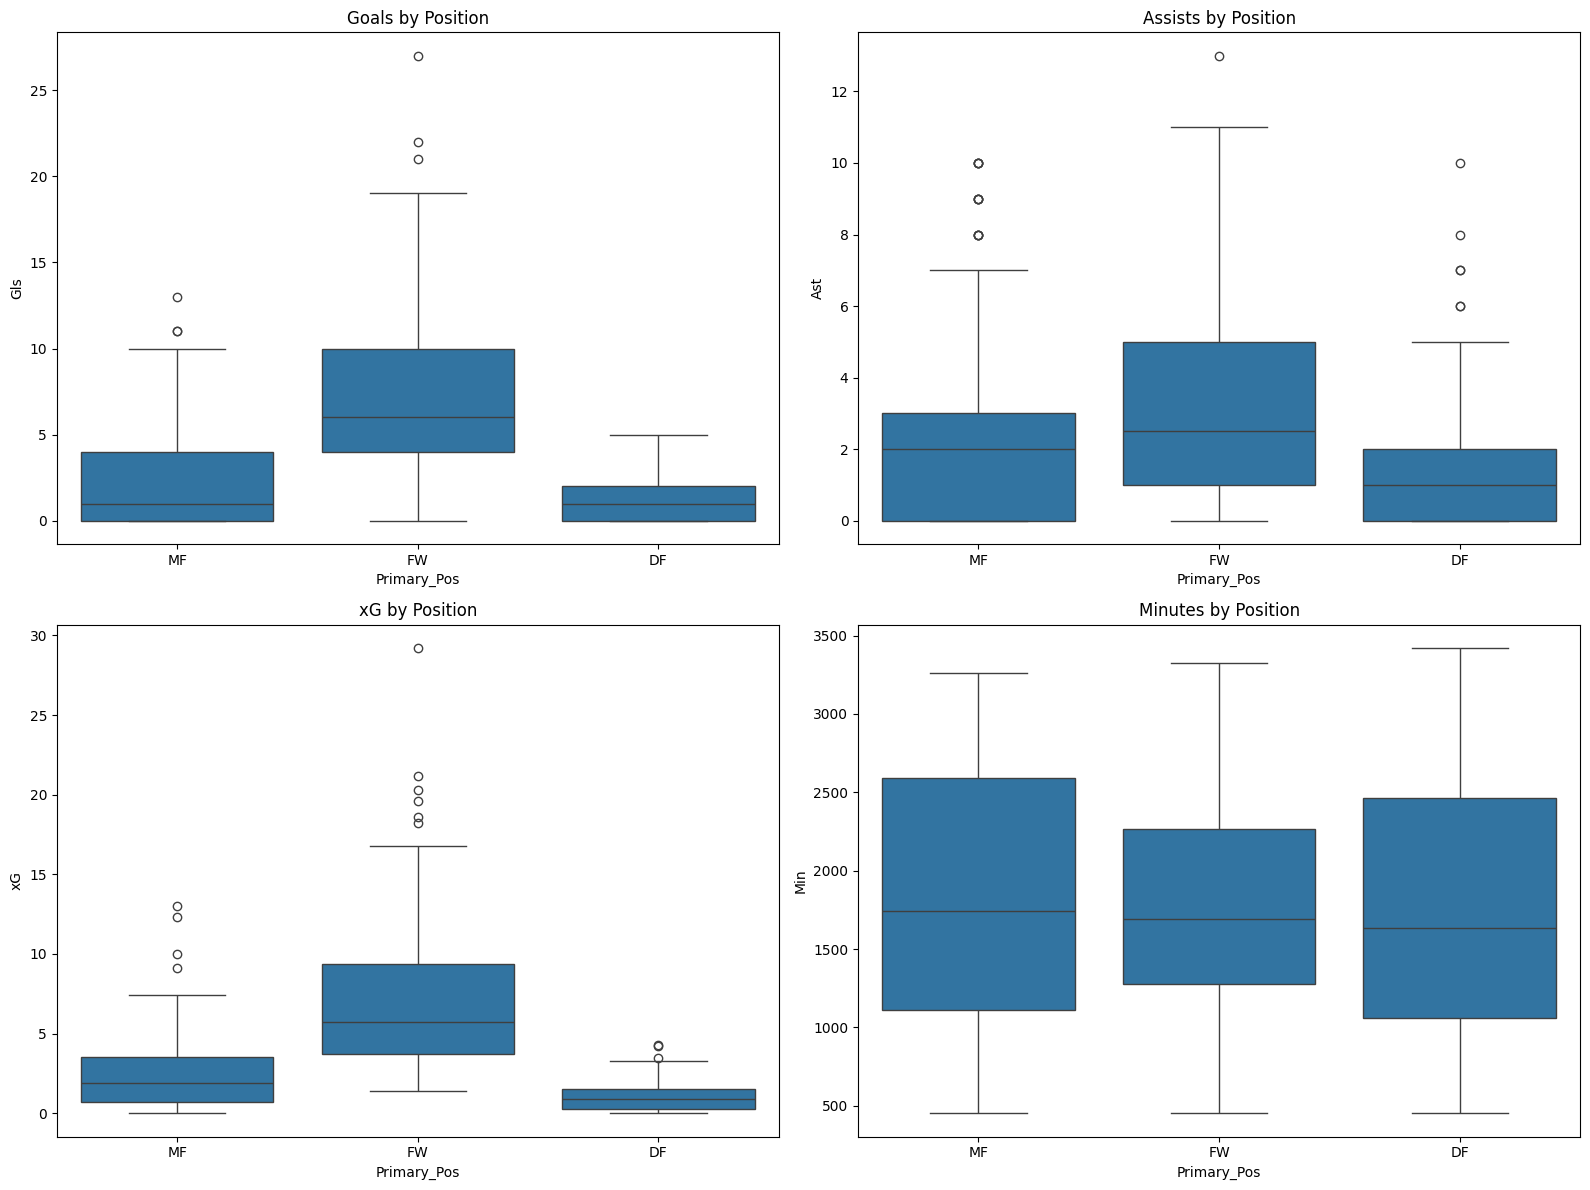

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Only outfield players with meaningful minutes
outfield = df[(df['Min'] >= 450) & (df['Pos'] != 'GK')].copy()
outfield['Primary_Pos'] = outfield['Pos'].apply(lambda x: str(x).split(',')[0])

sns.boxplot(data=outfield, x='Primary_Pos', y='Gls', ax=axes[0, 0])
axes[0, 0].set_title('Goals by Position')

sns.boxplot(data=outfield, x='Primary_Pos', y='Ast', ax=axes[0, 1])
axes[0, 1].set_title('Assists by Position')

sns.boxplot(data=outfield, x='Primary_Pos', y='xG', ax=axes[1, 0])
axes[1, 0].set_title('xG by Position')

sns.boxplot(data=outfield, x='Primary_Pos', y='Min', ax=axes[1, 1])
axes[1, 1].set_title('Minutes by Position')

plt.tight_layout()
plt.show()


# Re-save Cleaned Data


In [52]:
processed_file_path = 'processed_data.csv'
df.to_csv(processed_file_path, index=False)
print(f'Cleaned data re-saved to {processed_file_path}')


Cleaned data re-saved to processed_data.csv


# Conclusion & Key Takeaways

Based on the analysis of Premier League 2023-24 player statistics:

1. **Top Scoring Team:** Manchester City led with 94 total goals.
2. **Top Individual Scorer:** Erling Haaland (27 goals, 29.2 xG).
3. **Top Assist Provider:** Ollie Watkins (13 assists).
4. **xG Efficiency:** Some players significantly outperform their xG, indicating clinical finishing.
5. **Progressive Play:** Teams like Manchester City and Arsenal lead in progressive metrics.
6. **Discipline:** Yellow and red card distributions vary widely across teams.
7. **Age Profile:** Peak goal-scoring output tends to occur in the 23-30 age bracket.
